# App Usage Dataset

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
%matplotlib inline

mydata = pd.read_csv('appusage.csv')

## Part 1: Descriptive Statistics

In [56]:
mydata.head()

,education,social,productivity,entertainment,health,news,shopping,gender_male,gender_female,total_screen_time,high_productivity
0,0.076827,0.492805,0.215572,0.149463,0.027770,0.027766,0.009797,True,False,0.601115,0
1,0.171387,0.002895,0.487688,0.248667,0.033225,0.027934,0.028203,False,True,0.524756,1
2,0.165502,0.100736,0.276952,0.043966,0.101114,0.133528,0.178203,False,True,0.199674,1
3,0.123840,0.153937,0.008158,0.160425,0.032067,0.011537,0.510036,False,True,0.385417,0
4,0.003479,0.056738,0.059604,0.248472,0.203501,0.387059,0.041148,False,True,0.182236,0


In [57]:
mydata.tail(5)

,education,social,productivity,entertainment,health,news,shopping,gender_male,gender_female,total_screen_time,high_productivity
495,0.100984,0.085072,0.114238,0.051805,0.057569,0.450443,0.139889,True,False,0.594049,1
496,0.128036,0.010026,0.256009,0.028057,0.184561,0.212929,0.180381,False,True,0.014609,1
497,0.091520,0.190150,0.100378,0.407816,0.075639,0.071164,0.063333,True,False,0.557405,0
498,0.133766,0.118376,0.179656,0.236536,0.184500,0.002084,0.145083,True,False,0.879752,0
499,0.009626,0.050111,0.434191,0.056443,0.047542,0.028347,0.373740,False,True,0.356571,1


In [58]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   education          500 non-null    float64
 1   social             500 non-null    float64
 2   productivity       500 non-null    float64
 3   entertainment      500 non-null    float64
 4   health             500 non-null    float64
 5   news               500 non-null    float64
 6   shopping           500 non-null    float64
 7   gender_male        500 non-null    bool   
 8   gender_female      500 non-null    bool   
 9   total_screen_time  500 non-null    float64
 10  high_productivity  500 non-null    int64  
dtypes: bool(2), float64(8), int64(1)
memory usage: 36.3 KB


In [59]:
mydata.describe()

,education,social,productivity,entertainment,health,news,shopping,total_screen_time,high_productivity
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.155675,0.136752,0.135013,0.139534,0.147862,0.137673,0.147491,0.524949,0.514000
std,0.129648,0.118427,0.112989,0.120631,0.127215,0.122927,0.127527,0.296577,0.500305
min,0.000917,0.001349,0.000002,0.000090,0.000031,0.000061,0.000779,0.000520,0.000000
25%,0.055622,0.043653,0.045973,0.041335,0.046861,0.040852,0.051248,0.269253,0.000000
50%,0.123997,0.107921,0.109784,0.112316,0.112108,0.105916,0.113678,0.557223,1.000000
75%,0.226518,0.200320,0.187491,0.201673,0.217317,0.197720,0.207860,0.796066,1.000000
max,0.745479,0.713631,0.603699,0.702344,0.652900,0.613000,0.659702,0.999558,1.000000


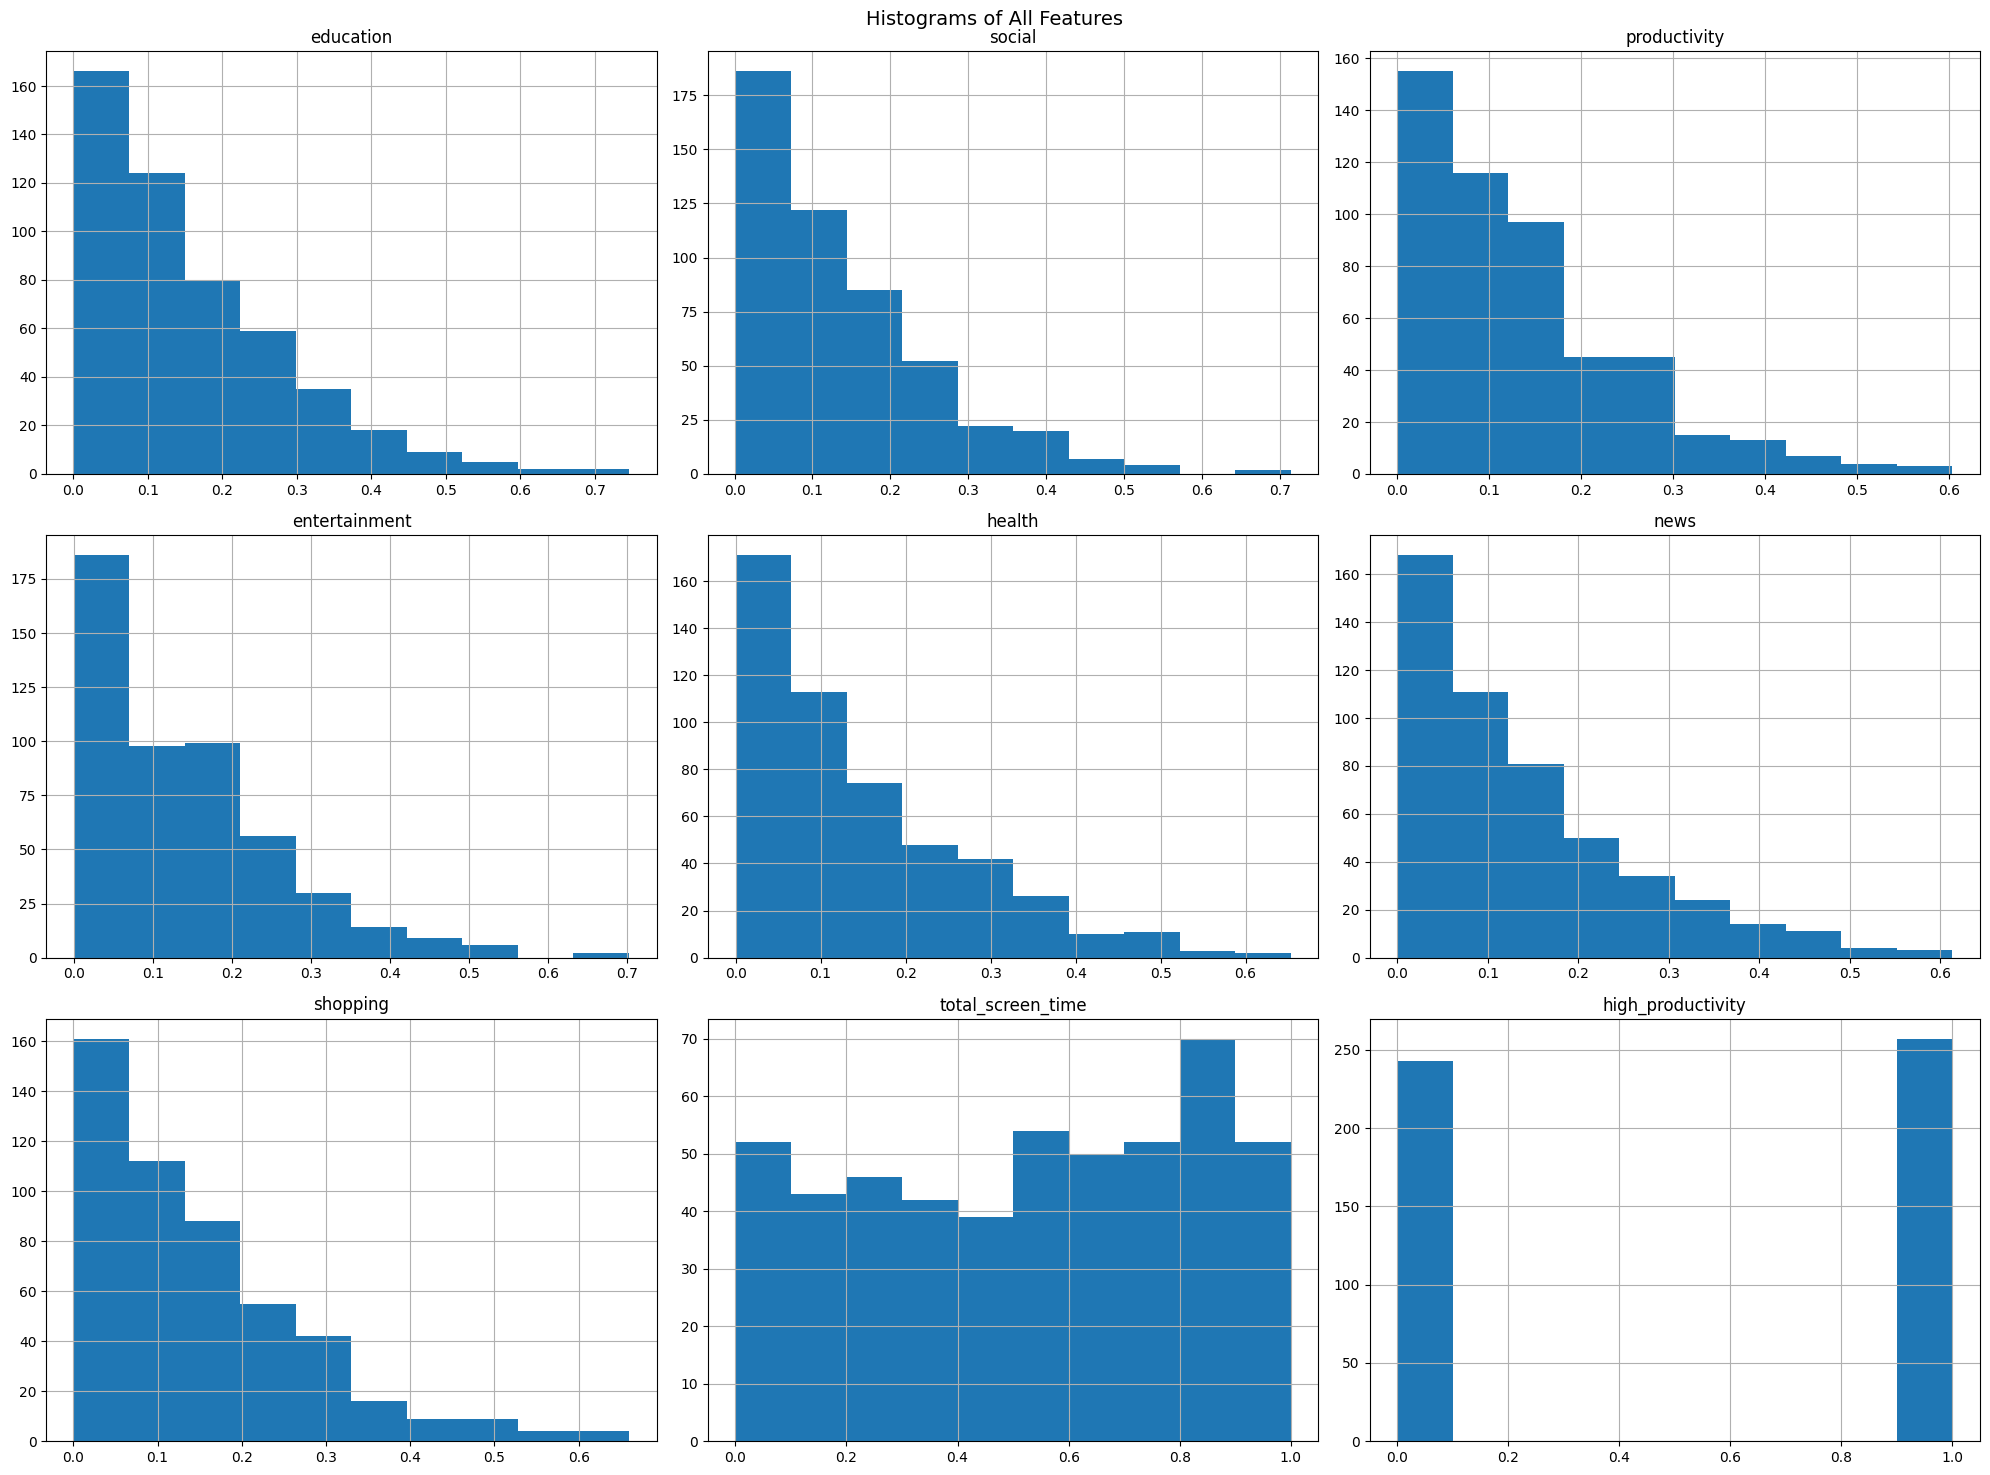

In [60]:
mydata.hist(figsize=(20, 15))
plt.suptitle('Histograms of All Features', fontsize=14)
plt.tight_layout()
plt.show()

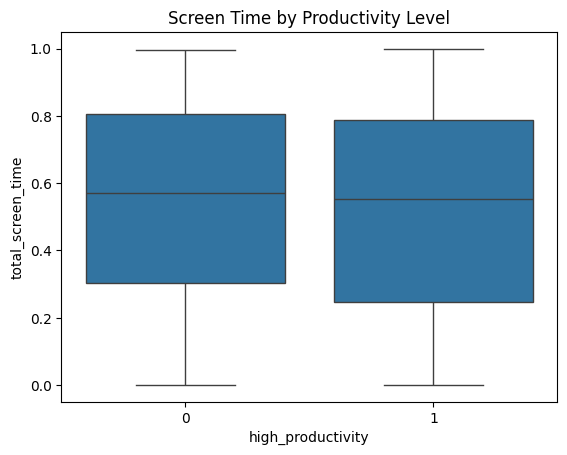

In [61]:
sns.boxplot(x='high_productivity', y='total_screen_time', data=mydata)
plt.title('Screen Time by Productivity Level')
plt.show()

In [62]:
pd.crosstab(mydata['high_productivity'], mydata['education'].apply(lambda x: 'high' if x > 0.15 else 'low'))

education,high,low
high_productivity,,
0,46,197
1,164,93


In [63]:
mydata['edu_group'] = mydata['education'].apply(lambda x: 'high' if x > 0.15 else 'low')
pd.pivot_table(mydata, 'total_screen_time', index=['high_productivity'], columns=['edu_group'])

edu_group,high,low
high_productivity,,
0,0.555701,0.535743
1,0.524486,0.487691


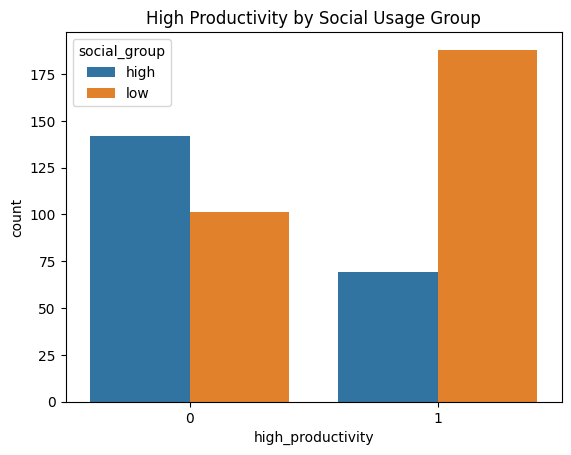

In [64]:
mydata['social_group'] = mydata['social'].apply(lambda x: 'high' if x > 0.13 else 'low')
sns.countplot(x='high_productivity', hue='social_group', data=mydata)
plt.title('High Productivity by Social Usage Group')
plt.show()

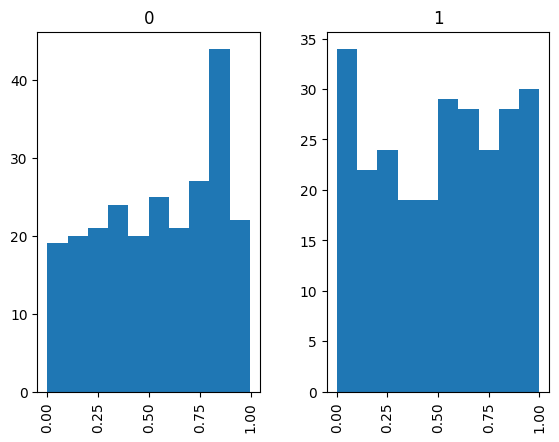

In [65]:
mydata.hist(by='high_productivity', column='total_screen_time')
plt.show()

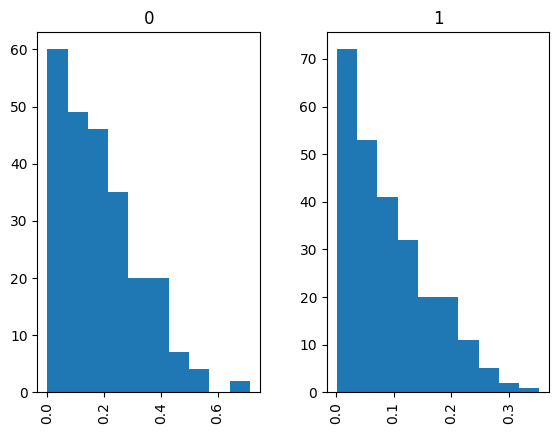

In [66]:
mydata.hist(by='high_productivity', column='social')
plt.show()

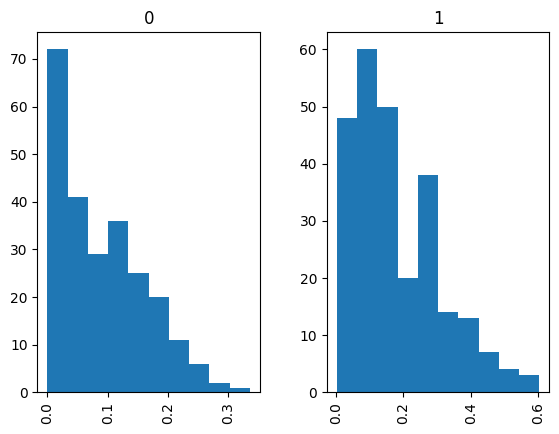

In [67]:
mydata.hist(by='high_productivity', column='productivity')
plt.show()

In [68]:
print('Mean total_screen_time:', mydata['total_screen_time'].mean())
print('Std  total_screen_time:', mydata['total_screen_time'].std())

Mean total_screen_time: 0.5249489081000001
Std  total_screen_time: 0.29657739498607355


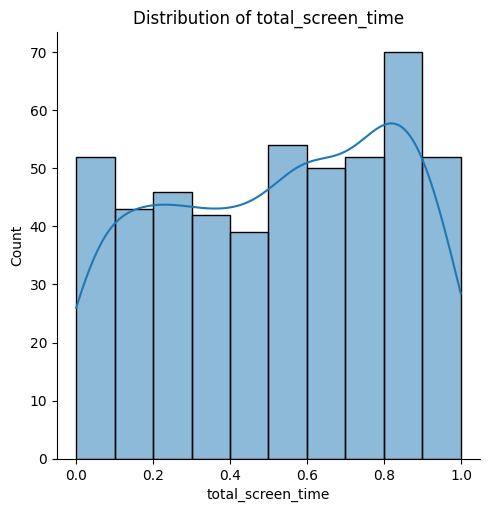

In [69]:
sns.displot(mydata['total_screen_time'], kde=True)
plt.title('Distribution of total_screen_time')
plt.show()

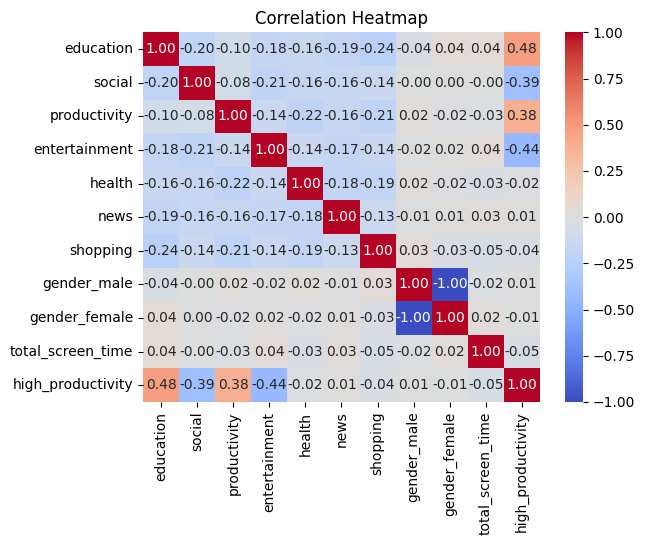

In [70]:
corr = mydata.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

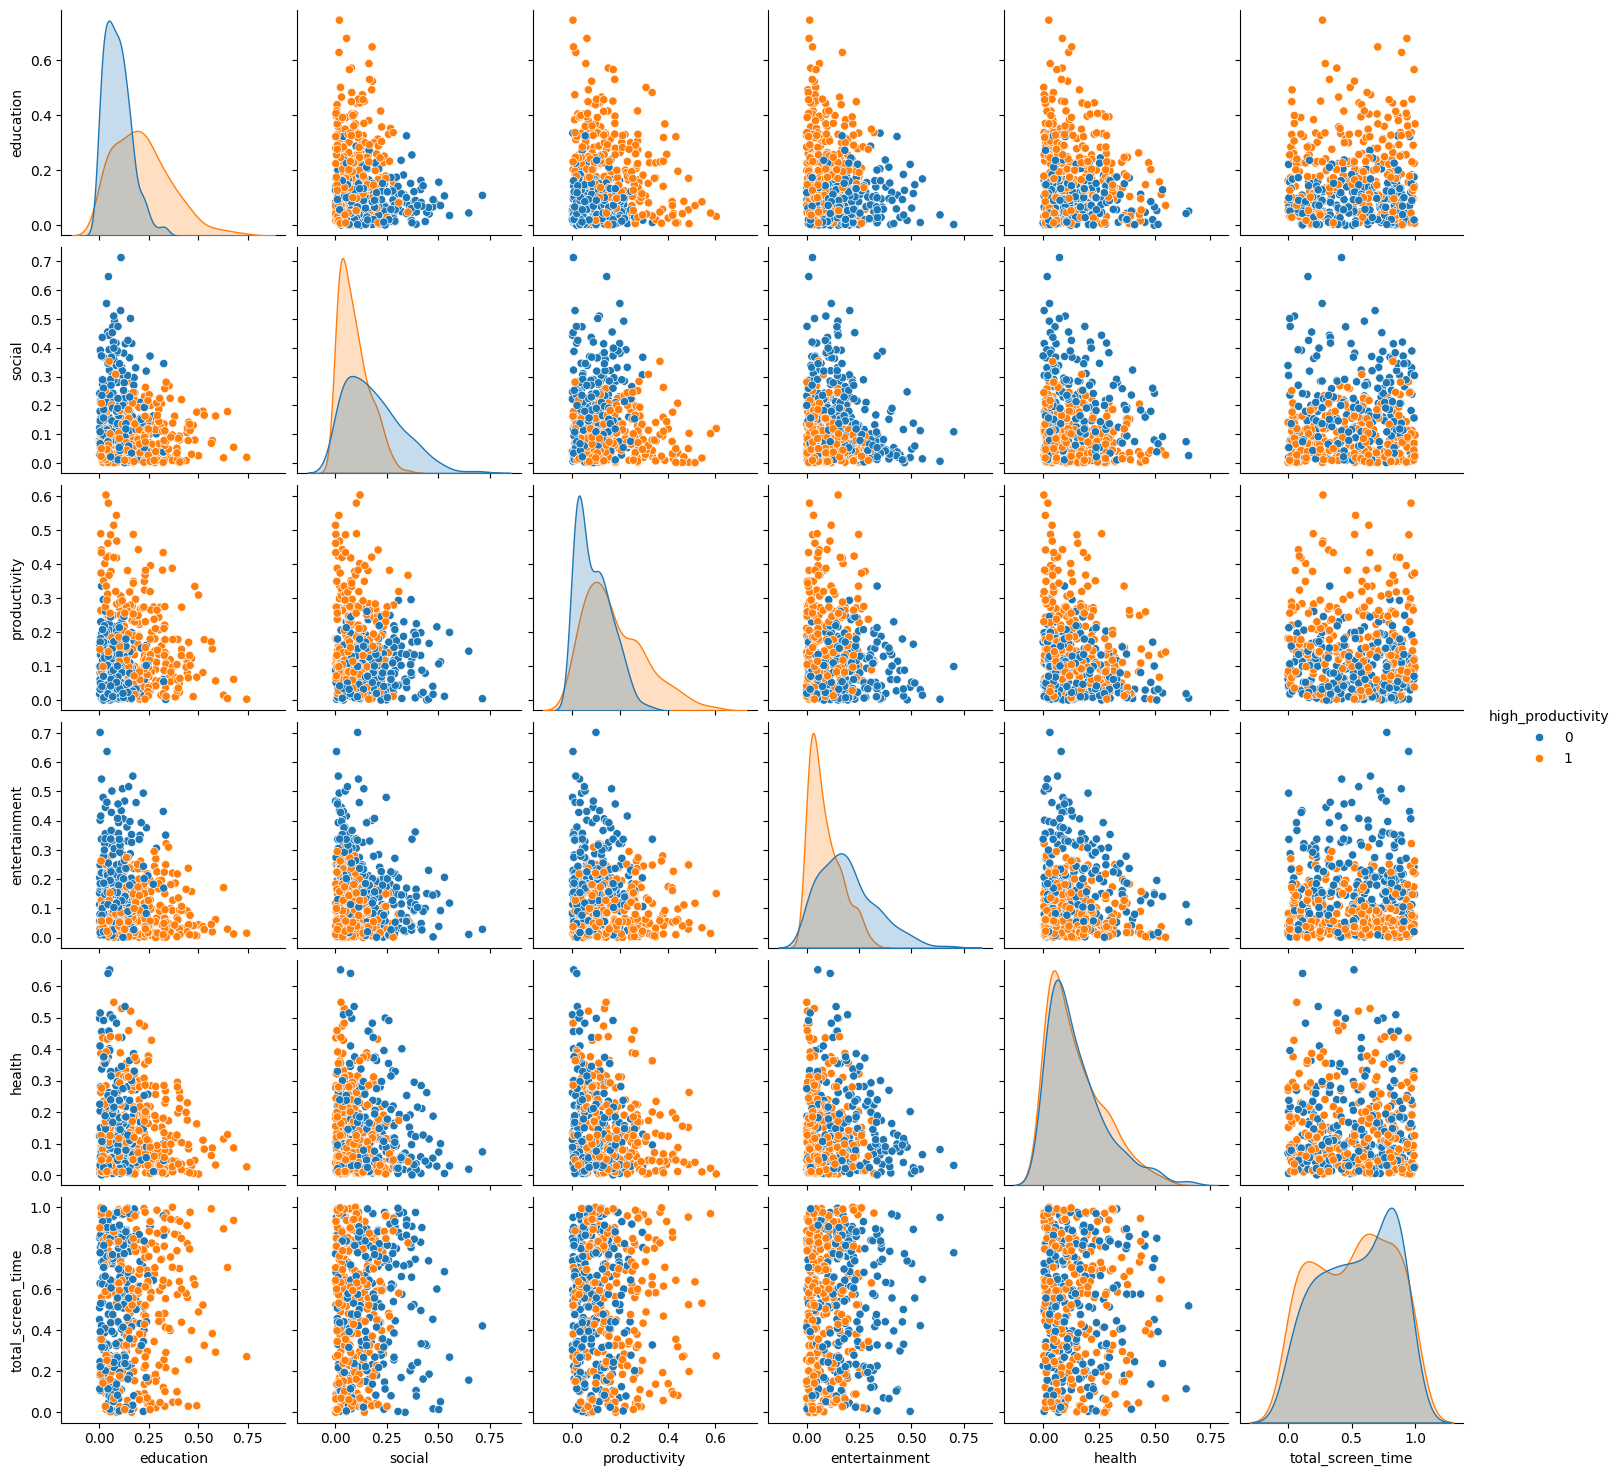

In [71]:
sns.pairplot(mydata[['education','social','productivity','entertainment','health','total_screen_time','high_productivity']], hue='high_productivity')
plt.show()

## Part 2: Basic Practice of Statistics

In [72]:
np.random.seed(42)
x = st.skewnorm.rvs(10, size=1000)

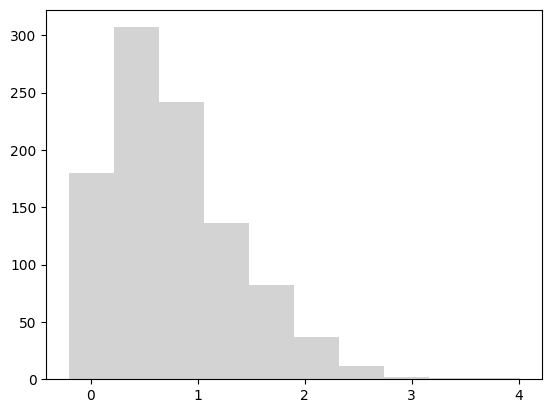

In [73]:
fig, ax = plt.subplots()
_ = plt.hist(x, color='lightgray')

### Mean

In [74]:
xbar = x.mean()
xbar

np.float64(0.7719211854654121)

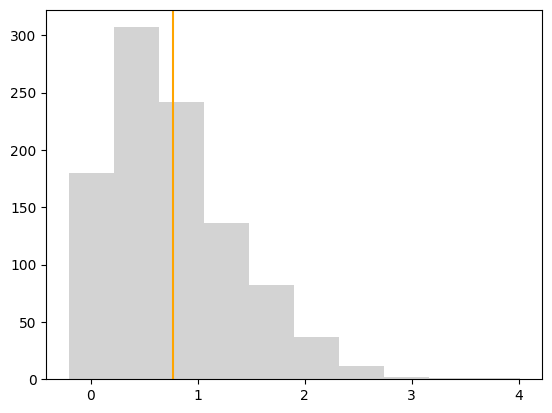

In [75]:
fig, ax = plt.subplots()
plt.axvline(x=x.mean(), color='orange')
_ = plt.hist(x, color='lightgray')

### Median

In [76]:
np.median(x)

np.float64(0.651420257427958)

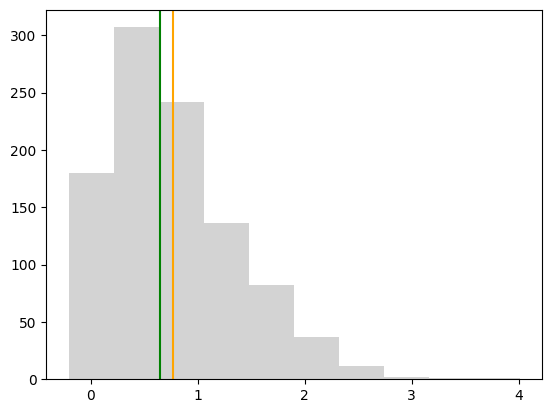

In [77]:
fig, ax = plt.subplots()
plt.axvline(x=np.mean(x), color='orange')
plt.axvline(x=np.median(x), color='green')
_ = plt.hist(x, color='lightgray')

### Variance

In [78]:
x.var()

np.float64(0.35528419278021617)

### Standard Deviation

In [79]:
sigma = x.std()
sigma

np.float64(0.5960572059628305)

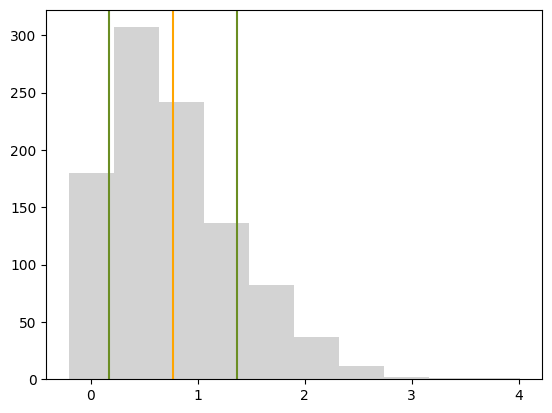

In [80]:
xbar = x.mean()
fig, ax = plt.subplots()
plt.axvline(x=xbar, color='orange')
plt.axvline(x=xbar+sigma, color='olivedrab')
plt.axvline(x=xbar-sigma, color='olivedrab')
_ = plt.hist(x, color='lightgray')

### Standard Error

In [81]:
sigma/(x.size)**(1/2)

np.float64(0.018848983865986414)

In [82]:
st.sem(x)

np.float64(0.018858415432183823)

### Gaussian / Normal Distribution

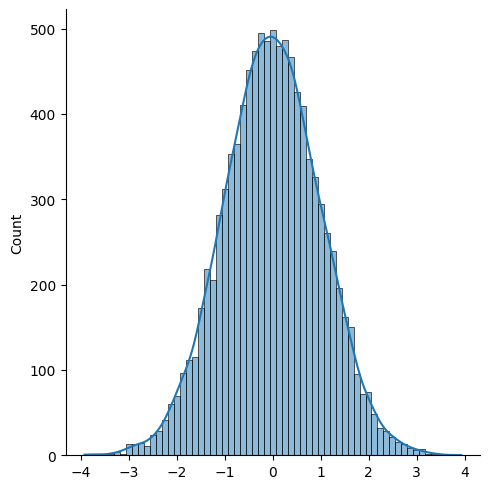

In [83]:
x = np.random.normal(size=10000)
_ = sns.displot(x, kde=True)

### Central Limit Theorem

In [84]:
def sample_mean_calculator(input_dist, sample_size, n_samples):
    sample_means = []
    for i in range(n_samples):
        sample = np.random.choice(input_dist, size=sample_size, replace=False)
        sample_means.append(sample.mean())
    return sample_means

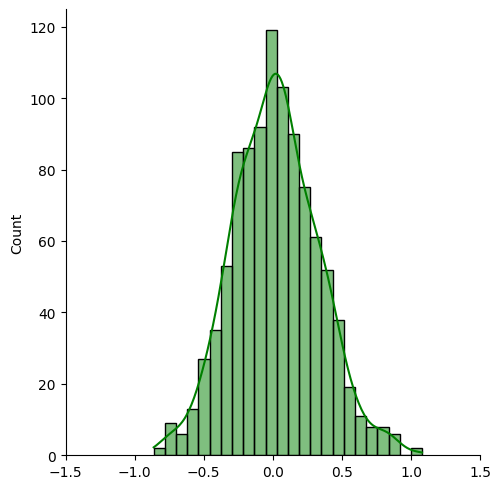

In [85]:
sns.displot(sample_mean_calculator(x, 10, 1000), color='green', kde=True)
_ = plt.xlim(-1.5, 1.5)

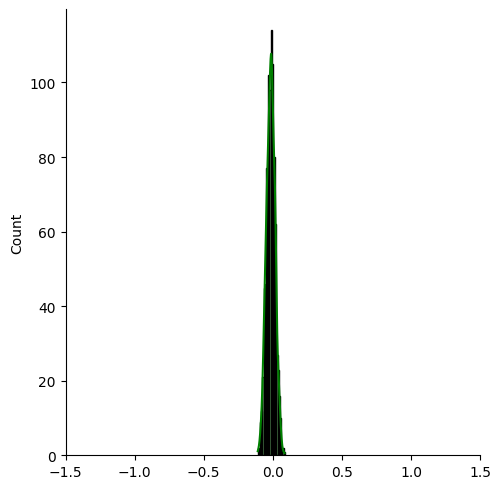

In [86]:
sns.displot(sample_mean_calculator(x, 1000, 1000), color='green', kde=True)
_ = plt.xlim(-1.5, 1.5)

### z-Scores

In [87]:
x_i = 85
mu = 60
sigma = 10
x = np.random.normal(mu, sigma, 10000)
z = (x_i - mu)/sigma
z

2.5

In [88]:
mu2 = 90
sigma2 = 2
y = np.random.normal(mu2, sigma2, 10000)
z2 = (x_i - mu2)/sigma2
z2

-2.5

### p-Values

In [89]:
p_below = st.norm.cdf(-2.5)
p_above = 1 - st.norm.cdf(2.5)
p_outside = p_below + p_above
p_outside

np.float64(0.01241933065155229)

In [90]:
def p_from_z(my_z):
    return 2 * st.norm.cdf(-abs(my_z))

p_from_z(2)

np.float64(0.04550026389635839)

### t-Tests

In [91]:
x = [48, 50, 54, 60]
st.ttest_1samp(x, 50)

TtestResult(statistic=np.float64(1.1338934190276817), pvalue=np.float64(0.3392540508564543), df=np.int64(3))

In [92]:
penguins = sns.load_dataset('penguins').dropna()
adelie = penguins[penguins.species == 'Adelie']
f = adelie[adelie.sex == 'Female']['body_mass_g'].to_numpy()/1000
m = adelie[adelie.sex == 'Male']['body_mass_g'].to_numpy()/1000
st.ttest_ind(f, m, equal_var=False)

TtestResult(statistic=np.float64(-13.126285923485879), pvalue=np.float64(6.402319748031518e-26), df=np.float64(135.69357893530386))

### Confidence Intervals

In [93]:
x = np.array([48, 50, 54, 60, 49, 55, 59, 62])
xbar = x.mean()
s = x.std()
n = x.size
z = 1.96
CI_err = z*(s/n**(1/2))
print(f'95% CI: ({xbar - CI_err:.2f}, {xbar + CI_err:.2f})')

95% CI: (51.16, 58.09)


### ANOVA

In [94]:
t = adelie[(adelie.sex == 'Female') & (adelie.island == 'Torgersen')]['body_mass_g'].to_numpy()/1000
b = adelie[(adelie.sex == 'Female') & (adelie.island == 'Biscoe')]['body_mass_g'].to_numpy()/1000
d = adelie[(adelie.sex == 'Female') & (adelie.island == 'Dream')]['body_mass_g'].to_numpy()/1000
st.f_oneway(t, b, d)

F_onewayResult(statistic=np.float64(0.2262775243854272), pvalue=np.float64(0.7980777848719268))

### Pearson Correlation

In [95]:
iris = sns.load_dataset('iris')
st.pearsonr(iris.sepal_length, iris.petal_length)

PearsonRResult(statistic=np.float64(0.8717537758865831), pvalue=np.float64(1.0386674194498771e-47))

### Linear Regression

In [96]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7.])
y = np.array([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])

cov_mat = np.cov(x, y)
beta1 = cov_mat[0,1]/cov_mat[0,0]
beta0 = y.mean() - beta1*x.mean()
print(f'beta0: {beta0:.4f}, beta1: {beta1:.4f}')

beta0: 1.7600, beta1: -0.4693


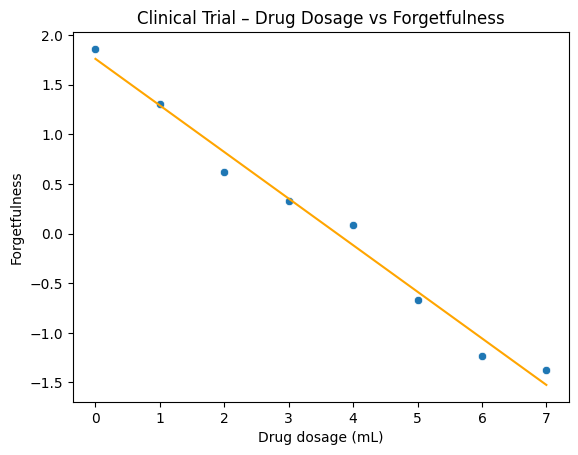

In [97]:
xline = np.linspace(0, 7, 1000)
yline = beta0 + beta1*xline
sns.scatterplot(x=x, y=y)
plt.plot(xline, yline, color='orange')
plt.title('Clinical Trial – Drug Dosage vs Forgetfulness')
plt.xlabel('Drug dosage (mL)')
plt.ylabel('Forgetfulness')
plt.show()

### Logistic Regression

In [98]:
titanic = sns.load_dataset('titanic')
titanic = titanic[['survived', 'sex', 'class', 'age']].dropna()

titanic['female'] = (titanic['sex'] == 'female').astype(int)
titanic['First']  = (titanic['class'] == 'First').astype(int)
titanic['Second'] = (titanic['class'] == 'Second').astype(int)

y = titanic['survived']
X = titanic[['First', 'Second', 'female', 'age']]
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.453279
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      709
Method:                           MLE   Df Model:                            4
Date:                Tue, 19 May 2026   Pseudo R-squ.:                  0.3289
Time:                        20:46:51   Log-Likelihood:                -323.64
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 2.074e-67
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3264      0.248     -5.351      0.000      -1.812      -0.841
First          2.5806      0.

## Part 3: Quartiles

In [99]:
data = np.array([85, 90, 78, 92, 88, 76, 95, 89, 82, 80])

mean_val = np.mean(data)
std_val  = np.std(data)
print(f'Mean: {mean_val:.2f}')
print(f'Standard Deviation: {std_val:.2f}')

Mean: 85.50
Standard Deviation: 6.00


In [100]:
z_scores = st.zscore(data)
print(f'Z-scores: {z_scores}')

z_input = 1.2
x_val = mean_val + (z_input * std_val)
print(f'Raw score (X) for Z=1.2: {x_val:.2f}')

Z-scores: [-0.08327552  0.74947971 -1.24913285  1.0825818   0.41637762 -1.58223494
  1.58223494  0.58292866 -0.58292866 -0.91603075]
Raw score (X) for Z=1.2: 92.70


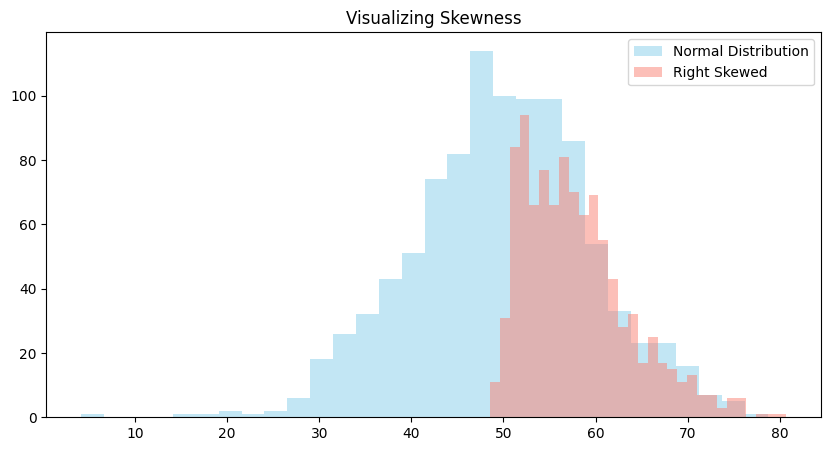

In [101]:
normal_dist = np.random.normal(50, 10, 1000)
skewed_dist = st.skewnorm.rvs(a=10, loc=50, scale=10, size=1000)

plt.figure(figsize=(10, 5))
plt.hist(normal_dist, bins=30, alpha=0.5, label='Normal Distribution', color='skyblue')
plt.hist(skewed_dist, bins=30, alpha=0.5, label='Right Skewed', color='salmon')
plt.title('Visualizing Skewness')
plt.legend()
plt.show()

In [102]:
prob = st.norm.cdf(80, loc=mean_val, scale=std_val)
print(f'Probability (X < 80): {prob:.4f}')

t_stat, p_val = st.ttest_1samp(data, 85)
print(f'P-Value: {p_val:.4f}')

Probability (X < 80): 0.1798
P-Value: 0.8083


Q1: 80.5, Median: 86.5, Q3: 89.75


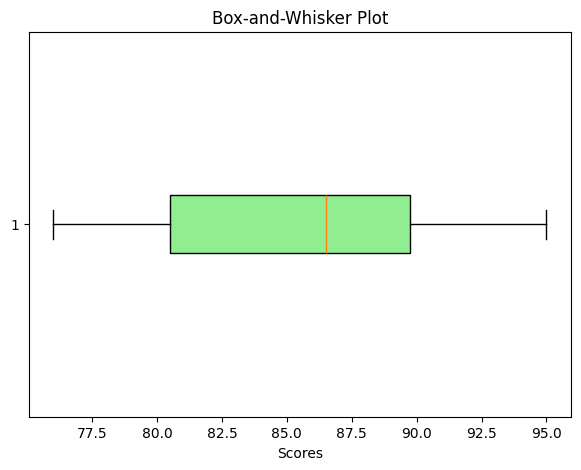

In [103]:
q1, q2, q3 = np.percentile(data, [25, 50, 75])
print(f'Q1: {q1}, Median: {q2}, Q3: {q3}')

plt.figure(figsize=(7, 5))
plt.boxplot(data, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'))
plt.title('Box-and-Whisker Plot')
plt.xlabel('Scores')
plt.show()

In [104]:
data2 = np.array([10, 85, 90, 78, 92, 88, 76, 95, 89, 82, 80, 200])

q1, q3 = np.percentile(data2, [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
outliers = data2[(data2 < lower_bound) | (data2 > upper_bound)]

mean_val2 = np.mean(data2)
std_val2  = np.std(data2)

def chebyshev_rule(k):
    if k <= 1:
        return 'k must be greater than 1'
    return (1 - (1 / k**2)) * 100

print(f'At least {chebyshev_rule(2):.2f}% within 2 SD')
print(f'At least {chebyshev_rule(3):.2f}% within 3 SD')

At least 75.00% within 2 SD
At least 88.89% within 3 SD


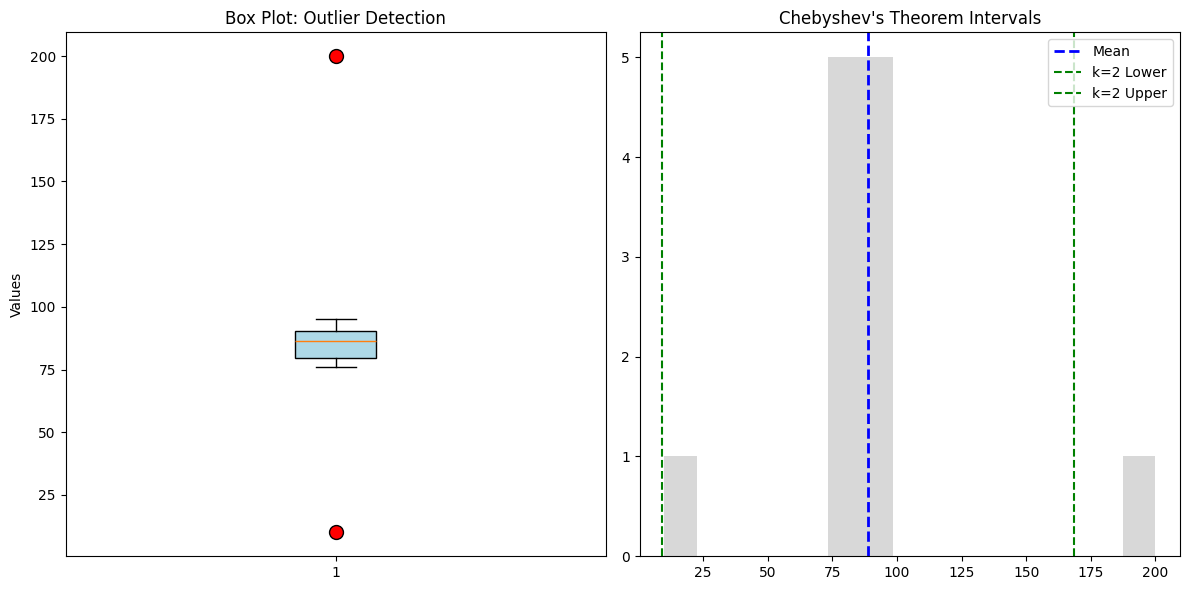

In [105]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(data2, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=10))
plt.title('Box Plot: Outlier Detection')
plt.ylabel('Values')

plt.subplot(1, 2, 2)
plt.hist(data2, bins=15, color='gray', alpha=0.3)
plt.axvline(mean_val2, color='blue', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(mean_val2 - 2*std_val2, color='green', linestyle='--', label='k=2 Lower')
plt.axvline(mean_val2 + 2*std_val2, color='green', linestyle='--', label='k=2 Upper')
plt.title("Chebyshev's Theorem Intervals")
plt.legend()

plt.tight_layout()
plt.show()

In [106]:
t_statistic, p_value = st.ttest_1samp(data, 85)
print(f'T-statistic: {t_statistic:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Decision: Reject the Null Hypothesis')
else:
    print('Decision: Fail to Reject the Null Hypothesis')

T-statistic: 0.2498
P-value: 0.8083
Decision: Fail to Reject the Null Hypothesis
